<a href="https://colab.research.google.com/github/pallavigeddam/cs207-section5-team4-project/blob/main/Pallavi_Stock_Classification_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Movement Classification (Pallavi)

Predicting next-day price direction for SPY, NVDA, MU, and TSLA as a 5-class problem.
This milestone notebook covers data loading, feature engineering, the look-ahead-safe
target, EDA, and a linear baseline.

In [2]:
#  0. Pre-run setup: install + API keys (run this cell first, then Run All) ─
!pip install -q "alpaca-py>=0.13"

import os
os.environ["ALPACA_API_KEY"] = "PKPL6PTRKCM4SAKLTEJOPS56BG"
os.environ["ALPACA_SECRET_KEY"] = "DBBYjabWeyQzJc1ZEbMFBtb2qbnGLRWjKGLNLF6VAGLA"
print("Setup cell done. Keys set:", bool(os.environ.get("ALPACA_API_KEY")))

Setup cell done. Keys set: True


## 1. Setup and Configuration

Everything tunable is in one place.

In [3]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Team-standard settings
SYMBOLS    = ["SPY", "NVDA", "MU", "TSLA"]
START, END = "2016-06-20", "2026-06-20"   # about 10 years of daily bars
TRAIN_FRAC = 0.70                          # 70% train, 15% val, 15% test (chronological)
VAL_FRAC   = 0.15
N_CLASSES  = 5                             # 5-class quantile target (team decision)
FLAT_K     = 0.33                          # only used if N_CLASSES == 3

USE_SYNTHETIC = False                      # set True to run offline without Alpaca keys
RANDOM_STATE  = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
print("Config loaded. Symbols:", SYMBOLS)

Config loaded. Symbols: ['SPY', 'NVDA', 'MU', 'TSLA']


In [4]:
def _synthetic_prices(symbols, start, end):
    # Offline fallback only. Makes fake but realistic-looking price paths so the
    # notebook can run end to end without network access. Not used for real results.
    dates = pd.bdate_range(start=start, end=end)
    n = len(dates); out = {}
    betas = {"SPY": 1.0, "NVDA": 1.7, "MU": 1.4, "TSLA": 1.8}
    for s in symbols:
        r = np.random.normal(4e-4, 0.012 * betas.get(s, 1.2), n)
        close = 100 * np.exp(np.cumsum(r))
        hi = close * (1 + np.abs(np.random.normal(0, 0.006, n)))
        lo = close * (1 - np.abs(np.random.normal(0, 0.006, n)))
        op = lo + (hi - lo) * np.random.rand(n)
        v  = np.random.lognormal(16, 0.4, n)
        df = pd.DataFrame({"open": op, "high": hi, "low": lo, "close": close, "volume": v}, index=dates)
        df.index.name = "date"; df["symbol"] = s
        out[s] = df
    return out

## 2. Data Acquisition

We pull daily OHLCV for each symbol from Alpaca into a dictionary keyed by ticker.
Keeping each symbol in its own frame means a rolling feature can never blend one
ticker's prices into another's.

Two settings matter:
1. `adjustment="all"` so stock splits and dividends are corrected. Without it the
   NVDA 10-for-1 (June 2024) and TSLA 3-for-1 (Aug 2022) splits show up as fake
   one-day crashes and poison the labels. Alpaca defaults to raw prices, so we set this on purpose.
2. Keys are read from environment variables, never typed into a cell.

In [5]:
def download_prices(symbols, start, end, feed="iex"):
    # Pull split/dividend-adjusted daily bars from Alpaca.
    import getpass
    from alpaca.data.historical import StockHistoricalDataClient
    from alpaca.data.requests import StockBarsRequest
    from alpaca.data.timeframe import TimeFrame
    from alpaca.data.enums import Adjustment, DataFeed

    key    = os.environ.get("ALPACA_API_KEY")    or getpass.getpass("Alpaca API key: ")
    secret = os.environ.get("ALPACA_SECRET_KEY") or getpass.getpass("Alpaca secret key: ")
    client = StockHistoricalDataClient(key, secret)

    req = StockBarsRequest(
        symbol_or_symbols=list(symbols),
        timeframe=TimeFrame.Day,
        start=pd.Timestamp(start), end=pd.Timestamp(end),
        adjustment=Adjustment.ALL,                              # the important fix
        feed=DataFeed.SIP if feed.lower() == "sip" else DataFeed.IEX,
    )
    bars = client.get_stock_bars(req).df    # MultiIndex (symbol, timestamp)

    out = {}
    for s in symbols:
        d = bars.loc[s].copy()
        idx = pd.DatetimeIndex(d.index)
        if idx.tz is not None:
            idx = idx.tz_localize(None)      # drop timezone, keep the calendar date
        d.index = idx.normalize(); d.index.name = "date"
        d = d[["open", "high", "low", "close", "volume"]].copy()
        d["symbol"] = s
        out[s] = d
    return out

if USE_SYNTHETIC:
    raw = _synthetic_prices(SYMBOLS, START, END)
    print("USING SYNTHETIC DATA (offline mode)")
else:
    raw = download_prices(SYMBOLS, START, END, feed="iex")
    print("Downloaded real data from Alpaca (adjustment=all, IEX feed)")

for s in SYMBOLS:
    print(f"  {s:5s} {raw[s].shape[0]:>5d} rows | {raw[s].index.min().date()} to {raw[s].index.max().date()}")

# total rows before any feature warmup is dropped (report this in the milestone)
rows_before = sum(raw[s].shape[0] for s in SYMBOLS)
print("Total raw rows across all symbols:", rows_before)
raw["SPY"].head()

Downloaded real data from Alpaca (adjustment=all, IEX feed)
  SPY    1483 rows | 2018-11-01 to 2026-06-18
  NVDA   1482 rows | 2020-07-27 to 2026-06-18
  MU     1482 rows | 2020-07-27 to 2026-06-18
  TSLA   1482 rows | 2020-07-27 to 2026-06-18
Total raw rows across all symbols: 5929


,open,high,low,close,volume,symbol
date,,,,,,
2018-11-01,241.54,241.54,241.54,241.54,200.0,SPY
2020-07-27,296.17,297.80,295.43,297.68,647693.0,SPY
2020-07-28,297.04,298.02,295.46,295.82,521475.0,SPY
2020-07-29,296.63,299.93,296.63,299.43,600377.0,SPY
2020-07-30,296.25,298.71,294.34,298.32,612074.0,SPY


## 3. Feature Engineering

All features are built per symbol and are **stationary** on purpose: returns, ratios,
and bounded indicators instead of raw price or volume levels. Raw price levels would
keep climbing over 10 years, so anything the scaler learned on the (cheaper) training
years would not match the (pricier) test years. Using returns and ratios avoids that.

The feature groups map to the team's indicator list like this:
- "Lagged price" becomes **momentum** over 10/20/30/50/100/200 days (return over k days).
- "Lagged volume" becomes **volume ratios** (volume vs its own moving average).
- SMAs (10/20/50/100/200) become **price-to-MA distance** so they stay comparable across years.
- RSI, MACD, and Bollinger %b are standard.

In [6]:
def add_features(df):
    # Work on one symbol at a time, sorted oldest to newest.
    df = df.sort_index().copy()
    close = df["close"]
    vol   = df["volume"]

    # daily returns (the core signal)
    df["ret_1"]   = close.pct_change()
    df["log_ret"] = np.log(close).diff()

    # yesterday / 2 days ago / 3 days ago returns (short-term memory)
    for lag in (1, 2, 3):
        df[f"ret_lag{lag}"] = df["ret_1"].shift(lag)

    # momentum over several horizons = return over the last k days
    # (this is the stationary stand-in for "lagged price")
    for k in (10, 20, 30, 50, 100, 200):
        df[f"mom_{k}"] = close / close.shift(k) - 1

    # moving averages: keep the raw MA for plotting, but feed the model the
    # distance from price to the MA (a ratio), which stays on the same scale across years
    for w in (10, 20, 50, 100, 200):
        ma = close.rolling(w).mean()
        df[f"ma_{w}"]         = ma
        df[f"price_to_ma{w}"] = close / ma - 1
    df["ma_cross"] = df["ma_50"] / df["ma_200"] - 1   # 50/200 crossover (golden vs death cross)

    # RSI (14, Wilder smoothing)
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["rsi_14"] = 100 - 100 / (1 + avg_gain / avg_loss)

    # MACD (12/26 EMAs, 9-day signal). Divided by price so the scale is stable over 10 years.
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df["macd"]        = (ema12 - ema26) / close
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]   = df["macd"] - df["macd_signal"]

    # Bollinger Bands turned into %b: where price sits inside the 20-day band (0 = bottom, 1 = top)
    mid   = close.rolling(20).mean()
    sd    = close.rolling(20).std()
    upper = mid + 2 * sd
    lower = mid - 2 * sd
    df["bb_pct"] = (close - lower) / (upper - lower)

    # realized volatility and how busy volume is vs its own average
    df["volatility_20"] = df["ret_1"].rolling(20).std()
    for w in (10, 20, 50):
        df[f"vol_ratio{w}"] = vol / vol.rolling(w).mean()

    # label source: NEXT day's return. Used ONLY to build the target, never as a feature.
    df["fwd_ret"] = close.pct_change().shift(-1)
    return df

feat = {s: add_features(raw[s]) for s in SYMBOLS}

# the columns the model actually sees (all stationary; raw price/MA levels are left out)
FEATURE_COLS = (
    ["ret_1", "log_ret", "ret_lag1", "ret_lag2", "ret_lag3"]
    + [f"mom_{k}" for k in (10, 20, 30, 50, 100, 200)]
    + [f"price_to_ma{w}" for w in (10, 20, 50, 100, 200)]
    + ["ma_cross", "rsi_14", "macd", "macd_signal", "macd_hist", "bb_pct", "volatility_20"]
    + [f"vol_ratio{w}" for w in (10, 20, 50)]
)
print(f"{len(FEATURE_COLS)} features per symbol")
feat["SPY"][["close", "mom_20", "rsi_14", "macd", "fwd_ret"]].tail()

26 features per symbol


,close,mom_20,rsi_14,macd,fwd_ret
date,,,,,
2026-06-12,739.76,-0.008604,52.952576,0.005120,0.017641
2026-06-15,752.81,0.021175,60.460227,0.006015,-0.005526
2026-06-16,748.65,0.016497,57.320131,0.006312,-0.012730
2026-06-17,739.12,0.009851,50.809776,0.005501,0.010323
2026-06-18,746.75,0.009927,55.197286,0.005506,NaN


## 4. Target Construction (look-ahead safe)

The label is the **next** day's move. The important detail: we assign the train/val/test
split first, then compute the class cut points from the **training rows only** and apply
those fixed cut points to val and test. If we computed the cut points on the whole dataset
(like a plain `qcut` on everything), the class boundaries would secretly know the future.
That is the bias we are avoiding.

- 5-class (default): quantile buckets (worst 20% up to best 20%), edges fit on train only.
- 3-class option: Up / Flat / Down using a volatility-scaled flat band, also from train only.

In [7]:
# global chronological split, shared across all symbols so they use the same cutoff dates
all_dates = sorted(set().union(*[set(feat[s].index) for s in SYMBOLS]))
N = len(all_dates)
TRAIN_END = all_dates[int(N * TRAIN_FRAC)]
VAL_END   = all_dates[int(N * (TRAIN_FRAC + VAL_FRAC))]
print(f"train <= {TRAIN_END.date()} | val <= {VAL_END.date()} | test > {VAL_END.date()}")

def split_tag(idx):
    if idx <= TRAIN_END: return "train"
    if idx <= VAL_END:   return "val"
    return "test"

def label_targets(df):
    df = df.copy()
    df["split"] = [split_tag(i) for i in df.index]
    train_fwd = df.loc[df.split == "train", "fwd_ret"].dropna()   # cut points come from train only

    if N_CLASSES == 3:
        tau = FLAT_K * train_fwd.std()           # flat band scaled by this symbol's volatility
        def lab(r):
            if pd.isna(r): return np.nan
            if r >  tau:   return 2               # Up
            if r < -tau:   return 0               # Down
            return 1                              # Flat
        df["target"] = df["fwd_ret"].apply(lab)
        df.attrs["cuts"] = ("tau", round(tau, 5))
    else:
        q = train_fwd.quantile([0.2, 0.4, 0.6, 0.8]).tolist()
        df["target"] = np.digitize(df["fwd_ret"], q).astype(float)
        df.loc[df["fwd_ret"].isna(), "target"] = np.nan
        df.attrs["cuts"] = ("quintiles", [round(x, 5) for x in q])
    return df

feat = {s: label_targets(feat[s]) for s in SYMBOLS}
LABELS = ["Down", "Flat", "Up"] if N_CLASSES == 3 else ["Worst 20%", "20-40%", "40-60%", "60-80%", "Best 20%"]

for s in SYMBOLS:
    dist = feat[s]["target"].value_counts(normalize=True).sort_index().round(3).to_dict()
    print(f"  {s:5s} cuts={feat[s].attrs['cuts'][1]}  dist={dist}")

train <= 2024-09-10 | val <= 2025-07-31 | test > 2025-07-31
  SPY   cuts=[-0.00691, -0.00124, 0.00274, 0.00889]  dist={0.0: 0.184, 1.0: 0.204, 2.0: 0.205, 3.0: 0.229, 4.0: 0.178}
  NVDA  cuts=[-0.0211, -0.00495, 0.00904, 0.02581]  dist={0.0: 0.189, 1.0: 0.203, 2.0: 0.215, 3.0: 0.204, 4.0: 0.19}
  MU    cuts=[-0.01897, -0.00467, 0.00634, 0.01977]  dist={0.0: 0.216, 1.0: 0.181, 2.0: 0.182, 3.0: 0.174, 4.0: 0.248}
  TSLA  cuts=[-0.02569, -0.00573, 0.00819, 0.02907]  dist={0.0: 0.2, 1.0: 0.207, 2.0: 0.198, 3.0: 0.192, 4.0: 0.204}


## 5. Train / Validation / Test Assembly

We stack all symbols into one table, drop the warmup rows that have no features yet
(the first 200 days need history for the long moving averages), and split by the tag we
just assigned. A hard assertion makes sure the forward return and the target never sneak
into the feature list.

In [8]:
full = pd.concat([feat[s].dropna(subset=FEATURE_COLS + ["target"]) for s in SYMBOLS])
full["target"] = full["target"].astype(int)

# safety check: the thing we predict must not be one of the inputs
assert "fwd_ret" not in FEATURE_COLS and "target" not in FEATURE_COLS, "TARGET LEAK!"

def xy(split):
    d = full[full.split == split]
    return d[FEATURE_COLS], d["target"]

Xtr, ytr = xy("train")
Xva, yva = xy("val")
Xte, yte = xy("test")

rows_after = len(full)
print(f"Rows after preprocessing: {rows_after}  (dropped {rows_before - rows_after} warmup/edge rows)")
print(f"  train: {len(Xtr):>5d}  ({full[full.split=='train'].index.min().date()} to {full[full.split=='train'].index.max().date()})")
print(f"  val  : {len(Xva):>5d}  ({full[full.split=='val'].index.min().date()} to {full[full.split=='val'].index.max().date()})")
print(f"  test : {len(Xte):>5d}  ({full[full.split=='test'].index.min().date()} to {full[full.split=='test'].index.max().date()})")

Rows after preprocessing: 5125  (dropped 804 warmup/edge rows)
  train:  3353  (2021-05-11 to 2024-09-10)
  val  :   888  (2024-09-11 to 2025-07-31)
  test :   884  (2025-08-01 to 2026-06-17)


## 6. Exploratory Data Analysis

Five quick views. The written takeaways below each plot describe what we expect to see on
the real Alpaca data.

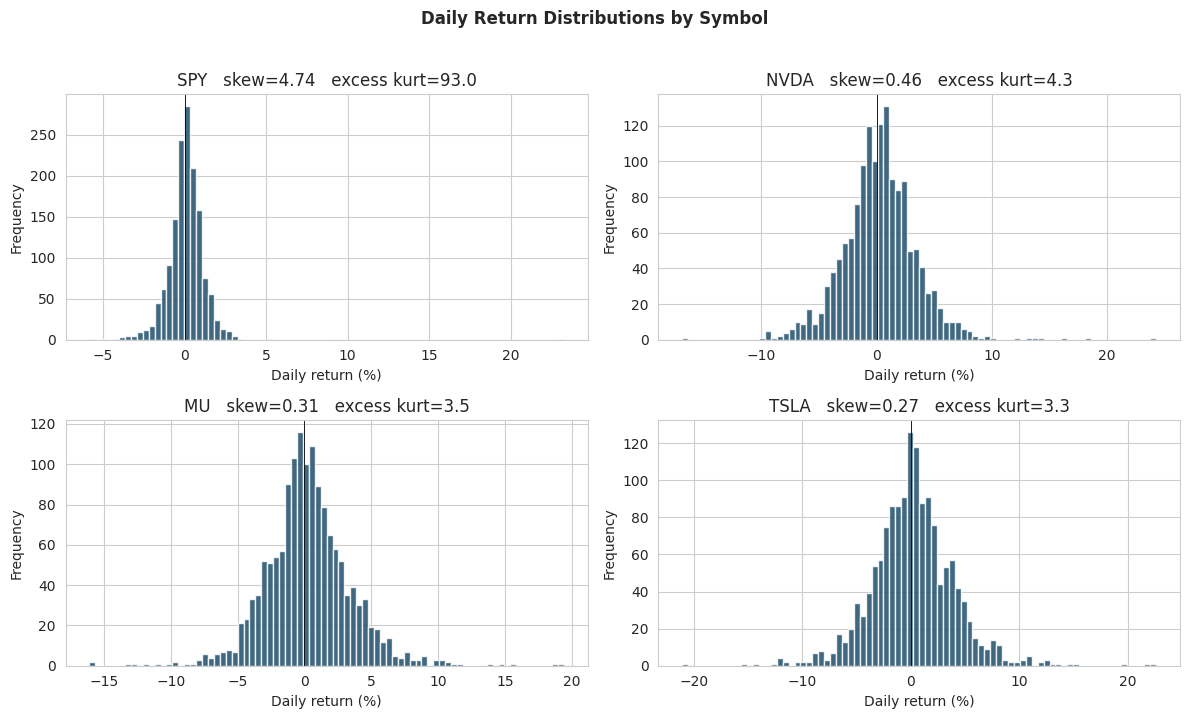

In [9]:
# 6.1 Daily return distributions by symbol
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, s in zip(axes.ravel(), SYMBOLS):
    r = feat[s]["ret_1"].dropna() * 100
    ax.hist(r, bins=80, color="#1f4e6b", alpha=0.85)
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(f"{s}   skew={skew(r):.2f}   excess kurt={kurtosis(r):.1f}")
    ax.set_xlabel("Daily return (%)"); ax.set_ylabel("Frequency")
fig.suptitle("Daily Return Distributions by Symbol", fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

**Takeaway.** Returns sit around zero with fat tails (high excess kurtosis), so big moves
happen more often than a normal curve would predict. The model should not assume returns are
Gaussian, and accuracy alone can be misleading, which is why we also track macro F1 later.

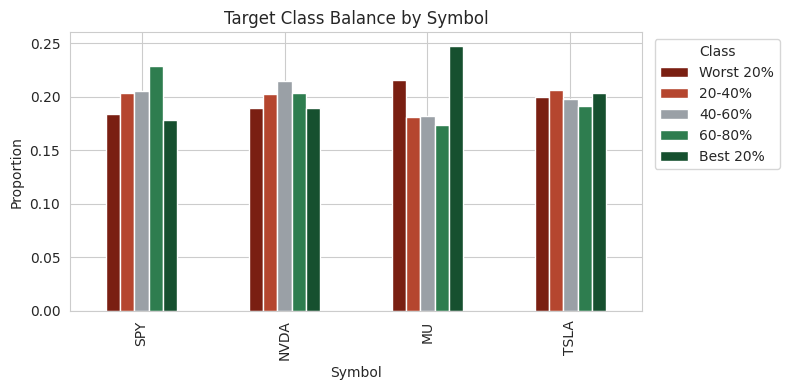

In [10]:
# 6.2 Target class balance per symbol
cb = pd.DataFrame({s: feat[s]["target"].value_counts(normalize=True).sort_index() for s in SYMBOLS})
cb.index = LABELS
colors = ["#b5462f", "#9aa0a6", "#2e7d4f"] if N_CLASSES == 3 else ["#7a1f12", "#b5462f", "#9aa0a6", "#2e7d4f", "#16502f"]
fig, ax = plt.subplots(figsize=(8, 4))
cb.T.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Target Class Balance by Symbol"); ax.set_ylabel("Proportion"); ax.set_xlabel("Symbol")
ax.legend(title="Class", bbox_to_anchor=(1.01, 1)); plt.tight_layout(); plt.show()

**Takeaway.** Because the cut points come from each symbol's own training returns, the
classes start out near 20% each. Small drift in the full-period bars just reflects volatility
changing between the training years and later years.

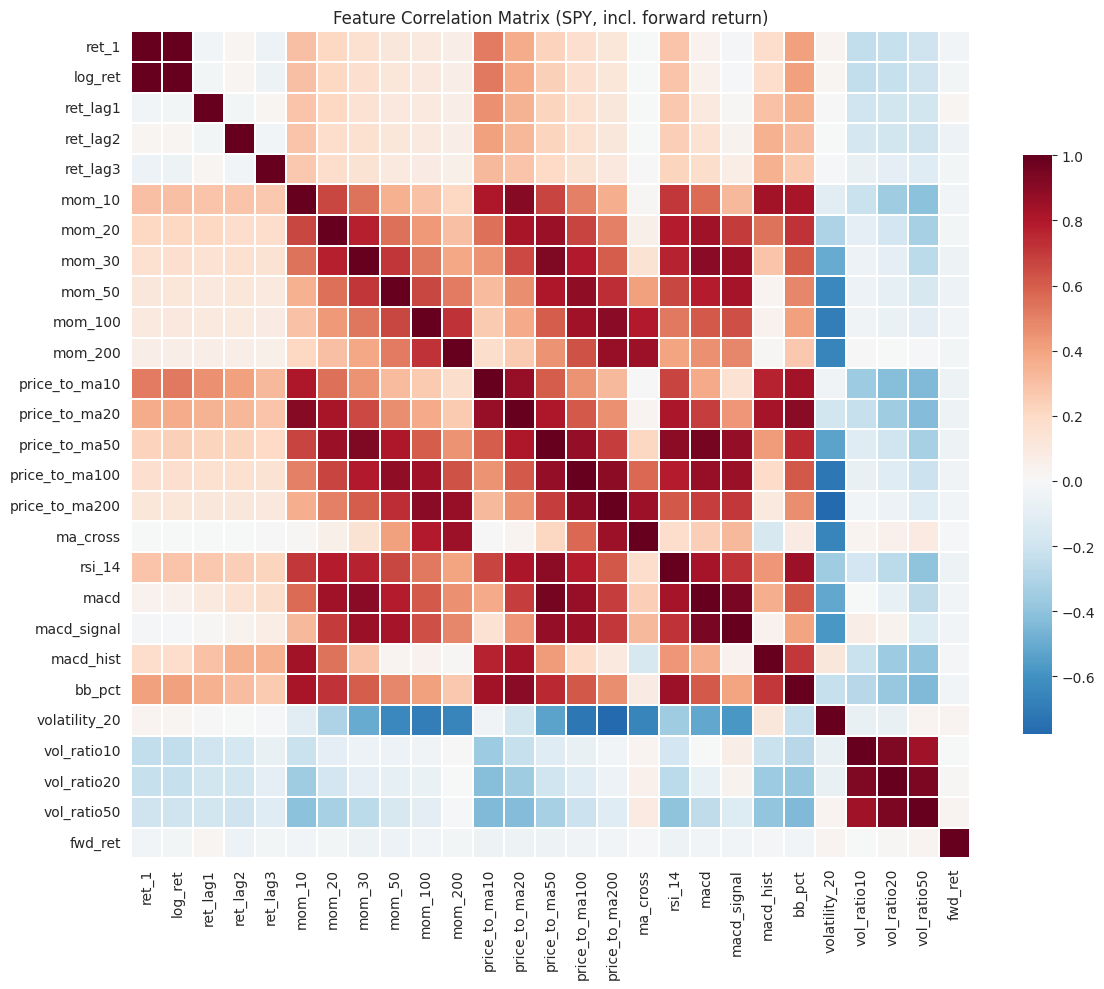

In [11]:
# 6.3 Feature correlation heatmap (SPY), including the forward return
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(feat["SPY"][FEATURE_COLS + ["fwd_ret"]].corr(), cmap="RdBu_r", center=0,
            ax=ax, cbar_kws={"shrink": 0.7}, linewidths=0.3)
ax.set_title("Feature Correlation Matrix (SPY, incl. forward return)")
plt.tight_layout(); plt.show()

**Takeaway.** Look at the `fwd_ret` row: correlations with next-day return are tiny for
every feature. That is the honest reality of daily prediction. The features are more
correlated with each other (the momentum and MA-distance blocks overlap), so the linear model
will see some redundancy.

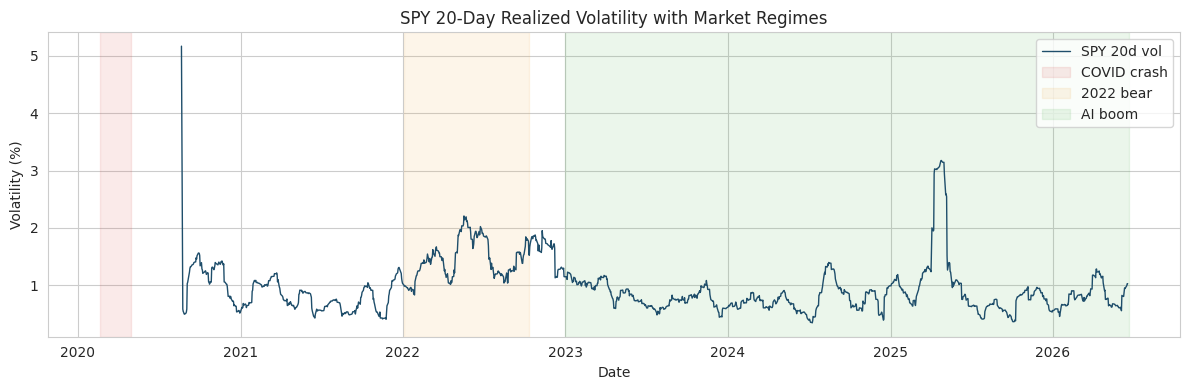

In [12]:
# 6.4 Rolling volatility with market regimes shaded
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(feat["SPY"].index, feat["SPY"]["volatility_20"] * 100, color="#1f4e6b", lw=1, label="SPY 20d vol")
for a, b, col, lbl in [("2020-02-19", "2020-04-30", "#d9534f", "COVID crash"),
                       ("2022-01-03", "2022-10-12", "#f0ad4e", "2022 bear"),
                       ("2023-01-01", str(pd.Timestamp(END).date()), "#5cb85c", "AI boom")]:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=col, alpha=0.12, label=lbl)
ax.set_title("SPY 20-Day Realized Volatility with Market Regimes")
ax.set_xlabel("Date"); ax.set_ylabel("Volatility (%)"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

**Takeaway.** Volatility clusters: calm stretches stay calm, then spike hard in the COVID
crash and the 2022 selloff. One static model has to handle very different regimes, which is why
we shade these periods now for a regime-by-regime check later.

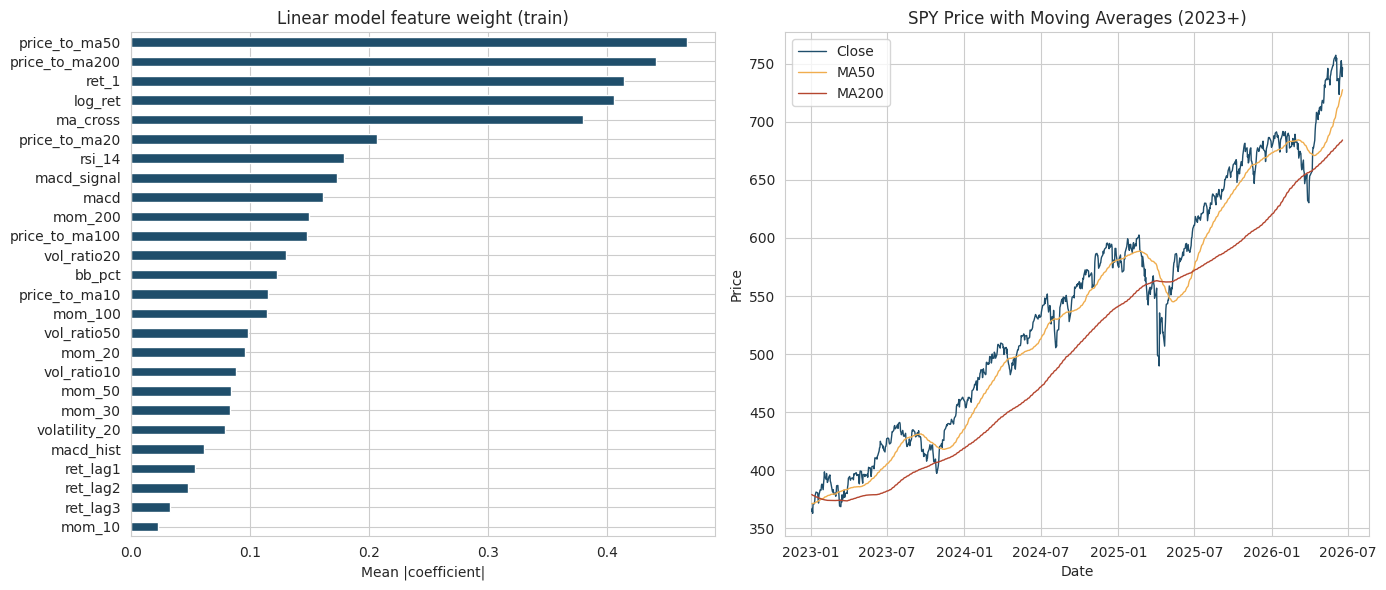

In [13]:
# 6.5 Feature weight from a quick linear fit + price/MA context
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

tr = full[full.split == "train"]
quick_scaler = StandardScaler().fit(tr[FEATURE_COLS])
quick_lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
quick_lr.fit(quick_scaler.transform(tr[FEATURE_COLS]), tr["target"])

# average absolute coefficient across the classes = how much weight each feature carries
weight = pd.Series(np.abs(quick_lr.coef_).mean(axis=0), index=FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
weight.plot(kind="barh", ax=axes[0], color="#1f4e6b")
axes[0].set_title("Linear model feature weight (train)"); axes[0].set_xlabel("Mean |coefficient|")

sp = feat["SPY"].loc["2023":]
axes[1].plot(sp.index, sp["close"], label="Close", color="#1f4e6b", lw=1)
axes[1].plot(sp.index, sp["ma_50"], label="MA50", color="#f0ad4e", lw=1)
axes[1].plot(sp.index, sp["ma_200"], label="MA200", color="#b5462f", lw=1)
axes[1].set_title("SPY Price with Moving Averages (2023+)")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Price"); axes[1].legend()
plt.tight_layout(); plt.show()

**Takeaway.** Weight is spread across momentum, volatility, and the MA-distance features
rather than piling onto one indicator. No single feature dominates, which lines up with the
weak correlations in 6.3.

## 7. Baseline and Linear Model

Two models:
1. **Majority class** (`DummyClassifier`): always predicts the most common training class.
   This is the floor every real model must beat.
2. **Multinomial logistic regression**: our linear model, trained on the scaled features.

The scaler is fit on training data only and reused on val and test. We report accuracy and
macro F1, plus a per-class report and a confusion matrix for the logistic model.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# scale using train stats only, then apply the same scaler to val and test
scaler = StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xva_s = scaler.transform(Xva)
Xte_s = scaler.transform(Xte)

# model 1: majority-class baseline (the floor)
majority = DummyClassifier(strategy="most_frequent").fit(Xtr_s, ytr)
maj_pred = majority.predict(Xte_s)

# model 2: multinomial logistic regression (our linear model)
logreg = LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)
logreg.fit(Xtr_s, ytr)
log_pred = logreg.predict(Xte_s)

print("Test-set results")
print(f"  Majority class : acc={accuracy_score(yte, maj_pred):.3f}  macroF1={f1_score(yte, maj_pred, average='macro'):.3f}")
print(f"  Logistic reg   : acc={accuracy_score(yte, log_pred):.3f}  macroF1={f1_score(yte, log_pred, average='macro'):.3f}")

print("\nPer-class report (logistic regression):")
print(classification_report(yte, log_pred, target_names=LABELS, digits=3, zero_division=0))

Test-set results
  Majority class : acc=0.176  macroF1=0.060
  Logistic reg   : acc=0.198  macroF1=0.189

Per-class report (logistic regression):
              precision    recall  f1-score   support

   Worst 20%      0.167     0.212     0.186       156
      20-40%      0.175     0.103     0.129       175
      40-60%      0.200     0.366     0.259       183
      60-80%      0.231     0.150     0.182       187
    Best 20%      0.228     0.158     0.187       183

    accuracy                          0.198       884
   macro avg      0.200     0.198     0.189       884
weighted avg      0.202     0.198     0.189       884



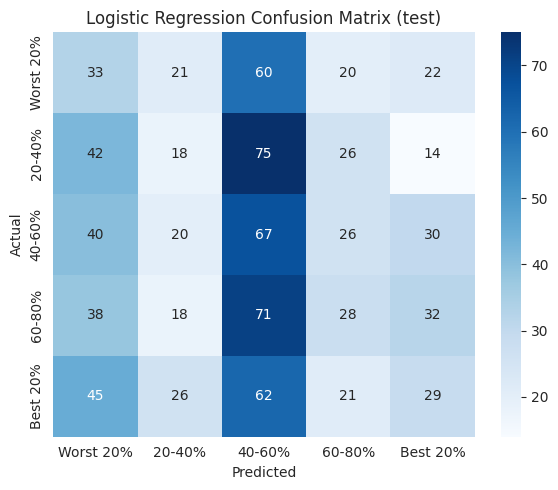

In [15]:
# confusion matrix for the logistic model on the test set
cm = confusion_matrix(yte, log_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Logistic Regression Confusion Matrix (test)")
plt.tight_layout(); plt.show()

**Takeaway.** On daily 5-class direction the linear model only edges out the majority
baseline, which is expected: a single day's move is close to random and a linear boundary can
only capture so much. This is an honest baseline, not a weak result to hide. The nonlinear and
sequence models (XGBoost and a TensorFlow LSTM) come in the next phase and are where we expect
any real lift.

## 8. Next Steps

1. Improvement models: XGBoost and a TensorFlow LSTM, compared on macro F1 with
   per-class recall and confusion matrices.
2. Swap the single split for walk-forward (expanding-window) validation.
3. Add market-wide context features (a volatility measure, a rate proxy, a credit proxy),joined on the same date to stay look-ahead safe.